# **Markov Decision Process (MDP)**

<hr>

### **Part 1**: Reinforcement Learning from Zero to One

*African Institute for Mathematical Sciences (AIMS), South Africa
2 Mar, 2026*

**Arnu Pretorius** - Head of Decision-Making AI Research, InstaDeep

<!--

Flow

* N=4, deterministic policy
* N=10, deterministic policy
* N=10, stochastic policy

-->





# **The Numberline Environment**

<!-- Start with num_state = 4 -->

In [1]:
# @title Setup
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.animation as animation

class NumberLineEnv:
    def __init__(self, num_states=10, max_steps=50, move_probability=0.95, reward_type='sparse'):
        self.num_states = num_states
        self.max_steps = max_steps
        self.reward_state = self.num_states-1
        self.move_probability = move_probability
        self.reward_type = reward_type

    def reset(self, key):
        """Initialize the environment state."""
        state = (0, 0, key)
        timestep = (0, 0, False)
        return state, timestep

    def step(self, state, action):
        """Takes an action in the environment."""
        obs, step_count, key = state
        new_key, sub_key = jax.random.split(key)

        # Determine movement direction (intended or opposite)
        intended_direction = jnp.where(jax.random.uniform(sub_key) < self.move_probability, action, -1)

        # Update position based on stochastic action
        next_obs = jnp.clip(obs + intended_direction, 0, self.reward_state)

        # Calculate reward
        is_at_goal = next_obs == self.reward_state
        reward = jax.lax.cond(
            self.reward_type == 'sparse',
            lambda x: jnp.where(x, 1, 0),
            lambda x: jnp.where(~x, -1, 0),
            is_at_goal,
        )
        done = (jnp.where(step_count == self.max_steps-1, 1, 0) + is_at_goal) > 0

        # Update state
        state = (next_obs, step_count + 1, new_key)
        timestep = (next_obs, reward, done)

        return state, timestep

    def _prepare_figure(self, ax):

        # Add labels and legend
        ax.set_xticks([])
        ax.set_yticks([])

    def _draw_state(self, ax, state):
        obs, _, _ = state

        # Create a line for the state space
        states = range(self.num_states)
        ax.plot(states, [0] * len(states), 'o-', color='gray', markersize=10)

        # Mark agent and target state
        ax.plot(self.num_states-1, 0)
        color = 'green' if obs == self.num_states - 1 else 'blue'
        ax.plot(obs, 0, 'o', color=color, markersize=15, label='Agent')

    def render(self, state):
        # Prepare figure and axis
        fig, ax = plt.subplots()
        ax.clear()
        self._prepare_figure(ax)

        # Mark the current state of the agent
        self._draw_state(ax, state)
        plt.show()

    def animate(self, states, interval=200, save_path=None):
        fig = plt.figure()
        fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)
        ax = fig.add_subplot(111)
        plt.close(fig)
        self._prepare_figure(ax)

        def make_frame(state) -> None:
            ax.clear()
            self._prepare_figure(ax)
            self._draw_state(ax, state)

        # Create the animation object.
        self._animation = animation.FuncAnimation(
            fig,
            make_frame,
            frames=states,
            interval=interval,
        )

        # Save the animation as a gif.
        if save_path:
            self._animation.save(save_path)

        return self._animation

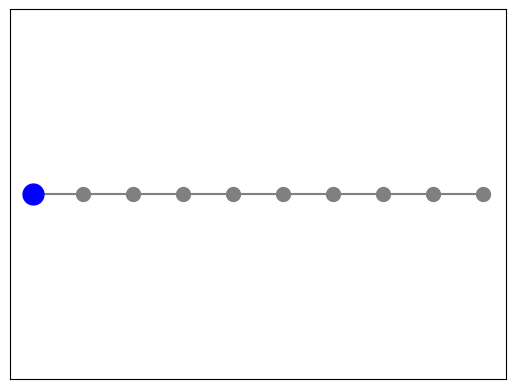

In [2]:
# create environment
num_states = 10
num_actions = 2
env = NumberLineEnv(num_states=num_states)
reset_fn = jax.jit(env.reset)
step_fn = jax.jit(env.step)

# visualise environment
key = jax.random.PRNGKey(3)
env_state, timestep = reset_fn(key)
env.render(env_state)

**States**: positions on the number line, i.e. 0, 1, ..., goal (last state on the right)

**Actions**: left, right

**Dynamics**: transition to next state

In [3]:
def make_deterministic_policy(fixed_key, probs=None):
    def policy(x, key=None):
        return jax.random.choice(fixed_key, jnp.array([-1, 1]), shape=(num_states,))[x]
    return policy

def make_stochastic_policy(burn_key, probs=None):
    if probs is None:
        probs = jnp.array([0.5, 0.5])
    def policy(x, key):
        key, sub_key = jax.random.split(key)
        return jax.random.choice(sub_key, jnp.array([-1, 1]), p=probs)
    return policy

def sample_policy(policy, key):
    keys = jax.random.split(key, num_states)
    return jnp.array([policy(x, key) for x, key in enumerate(keys)])

**Policy**: recipe/strategy for what action to take in a given state

In [7]:
##########################################
# Change for different types of policies #
##########################################
#policy_fn = make_deterministic_policy
policy_fn = make_stochastic_policy


key, policy_key = jax.random.split(key)
policy = policy_fn(policy_key)

In [8]:
key, subkey = jax.random.split(key)
sample_policy(policy, subkey)

Array([ 1, -1, -1,  1,  1,  1, -1,  1, -1,  1], dtype=int32)

In [9]:
from matplotlib import rc
rc('animation', html='jshtml')

def animation_rollout(policy, key):
    env_state, (obs, _, done) = reset_fn(key)
    env_states = [env_state]
    while not done:
        key, subkey = jax.random.split(key)
        action = policy(obs, subkey)
        env_state, (obs, _, done) = step_fn(env_state, action)
        env_states.append(env_state)
    return env_states

env_states = animation_rollout(policy, key)
env.animate(env_states)

### **The objective of RL? *To find an optimal policy***

What does optimal mean?

**Rewards**: 1 at the goal state, 0 everywhere else

**Episode**: running the policy until the goal state is reached, or some other defined termination condition

**Return**: sum of discounted rewards

$$G_0 = R_1 + \gamma R_2 + \gamma^2 R_3 + ... + \gamma^{T-1} R_T$$



# **Random policy *sampling***

In [10]:
def rollout_episode(key, p=None):
    reset_key, policy_key = jax.random.split(key)
    policy = policy_fn(policy_key, p)
    initial_state = reset_fn(reset_key)

    def check_if_env_is_done(state):
        done = state[1][2]
        return ~done

    def step_with_random_action(state):
        env_state, _ = state
        obs, _, key = env_state
        key, subkey = jax.random.split(key)
        action = policy(obs, subkey)
        return step_fn(env_state, action)

    # Run the episode loop
    env_state, timestep = jax.lax.while_loop(check_if_env_is_done, step_with_random_action, initial_state)
    final_obs, num_steps, _ = env_state

    return policy_key, num_steps

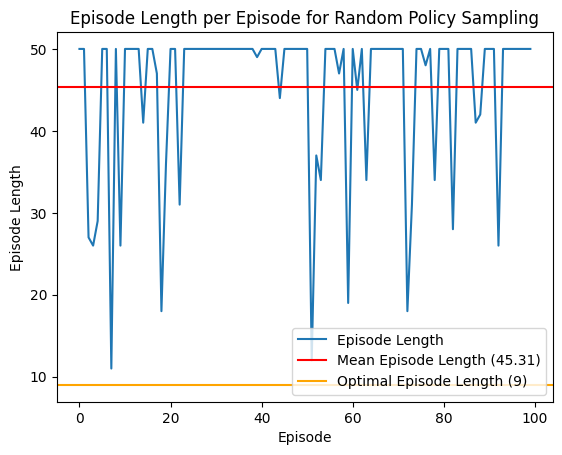

In [11]:
simulate_episodes_fn = jax.jit(jax.vmap(rollout_episode))

# Example usage
num_episodes = 100
key = jax.random.PRNGKey(2)
reset_key, policy_key = jax.random.split(key)
keys = jax.random.split(reset_key, num_episodes)  # Generate random keys for each episode
probs = jnp.tile(jnp.array([0.5, 0.5]), (num_episodes, 1)) # Probs for stochastic policy
final_obs, episode_lengths = simulate_episodes_fn(keys, probs)

# Calculate the mean episode length
mean_episode_length = jnp.mean(episode_lengths)
min_episode_length = jnp.min(episode_lengths)

# Plotting the episode lengths with the mean
plt.plot(range(num_episodes), episode_lengths, label='Episode Length')
plt.axhline(y=mean_episode_length, color='r', linestyle='-', label=f'Mean Episode Length ({mean_episode_length:.2f})')
plt.axhline(y=num_states-1, color='orange', linestyle='-', label=f'Optimal Episode Length ({num_states-1})')

plt.xlabel('Episode')
plt.ylabel('Episode Length')
plt.title('Episode Length per Episode for Random Policy Sampling')
plt.legend()
plt.show()

# **Random policy *search***

### --- Algorithm ---

* **Step 1**: Randomly sample a policy

* **Step 2**: Run an episode

* **Step 3**: Calculate the return from the starting state 0

* **Step 4**: If the return is better than the previous run, set the current policy as the best

* **Step 5**: Repeat

In [12]:
def deterministic_mutation(key, probs):
    key, subkey = jax.random.split(key)
    return (key, subkey), jnp.array([0.5, 0.5])

def stochastic_mutation(key, probs):
    _, subkey = jax.random.split(key)
    noise = jax.random.normal(subkey)
    probs += jnp.array([0, noise])
    probs = jax.nn.softmax(probs)
    return (subkey, key), probs

mutation_fn = deterministic_mutation if policy_fn == make_deterministic_policy else stochastic_mutation

In [13]:
def random_policy_search(key, num_iterations=100, num_episodes=50):
    """ Performs a basic random policy search. """

    def evaluate_policy(key, probs):
        keys = jnp.tile(key, (num_episodes, 1))
        probs = jnp.tile(probs, (num_episodes, 1))
        policy_keys, episode_lengths = simulate_episodes_fn(keys)
        return policy_keys[-1], jnp.mean(episode_lengths)

    best_probs = jnp.array([0.5, 0.5])
    best_policy_key, best_performance = evaluate_policy(key, best_probs)
    performance_history = [best_performance]

    for _ in range(num_iterations):

        # mutate
        (key, subkey), new_probs = mutation_fn(key, best_probs)

        # Evaluate new policy
        new_policy_key, new_performance = evaluate_policy(subkey, new_probs)

        # Update policy if performance improved
        if new_performance < best_performance:
            best_performance = new_performance
            best_policy_key = new_policy_key
            best_probs = new_probs

        performance_history.append(best_performance)

    return best_policy_key, best_probs, performance_history

# Run the random policy search
key = jax.random.PRNGKey(1)
final_policy_key, best_probs, performance_history = random_policy_search(key)
final_policy = policy_fn(final_policy_key, best_probs)

if policy_fn == make_deterministic_policy:
    print(sample_policy(final_policy, key))
else:
    print(best_probs)

[0.49962035 0.5003796 ]


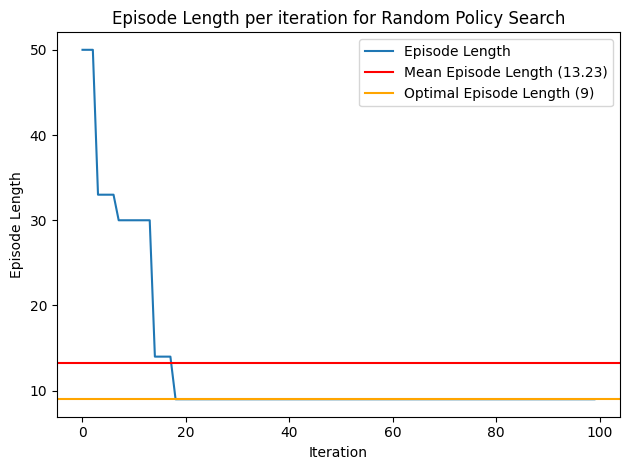

In [14]:
performance_history = jnp.array(performance_history)

# Plotting the episode lengths for the final policy
plt.plot(range(num_episodes), performance_history[1:], label='Episode Length')
plt.axhline(y=jnp.mean(performance_history), color='r', linestyle='-', label=f'Mean Episode Length ({jnp.mean(performance_history):.2f})')
plt.axhline(y=num_states-1, color='orange', linestyle='-', label=f'Optimal Episode Length ({num_states-1})')
plt.xlabel('Iteration')
plt.ylabel('Episode Length')
plt.title('Episode Length per iteration for Random Policy Search')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# make animation of random policy
key, subkey = jax.random.split(key)
states = animation_rollout(final_policy, subkey)
env.animate(states)

What is the probability of sampling the optimal deterministic policy?

In [16]:
# probability of sampling the optimal deterministic policy
print(f'{((0.5)**num_states)*100}%')

0.09765625%
